In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

In [2]:
data_dir = '/Users/shtian/Desktop/KI/research/cultural_transmission/data'
df_advice = pd.read_csv(os.path.join(data_dir, 'data_advice_lemma.csv'))
df = pd.read_csv('data/data_stakes_fitting.csv')

In [3]:
df_advice.head()

,doc_id,sentence_id,token_id,token,lemma,pos,entity,ID,gen
0,doc1,1,2,found,find,VERB,NaN,54249d5bfdf99b691e6ac9a0,9
1,doc1,1,6,neon,neon,NOUN,NaN,54249d5bfdf99b691e6ac9a0,9
2,doc1,1,7,colors,color,NOUN,NaN,54249d5bfdf99b691e6ac9a0,9
3,doc1,1,8,along,along,ADP,NaN,54249d5bfdf99b691e6ac9a0,9
4,doc1,1,10,lines,line,NOUN,NaN,54249d5bfdf99b691e6ac9a0,9


In [4]:
corpus_id = df_advice['ID'].unique()
corpus = [df_advice['lemma'][df_advice['ID'] == id].tolist() for id in corpus_id]

In [5]:
# Creating document-term matrix 
dictionary = corpora.Dictionary(corpus)
doc_term_matrix = [dictionary.doc2bow(doc) for doc in corpus]

In [6]:
dictionary.filter_extremes(no_below=5, no_above=0.5)
doc_term_matrix_filtered = [dictionary.doc2bow(doc) for doc in corpus]

In [7]:
# LDA model
lda = LdaModel(corpus  = doc_term_matrix_filtered, 
               id2word = dictionary,
               num_topics=2,
               passes=10,
               alpha='auto',
               eta='auto',
               random_state=1)

# Results
print(lda.print_topics(num_topics=2, num_words=10))

[(0, '0.028*"mushroom" + 0.026*"give" + 0.020*"point" + 0.017*"one" + 0.017*"good" + 0.017*"seem" + 0.017*"try" + 0.016*"time" + 0.015*"high" + 0.015*"change"'), (1, '0.081*"basket" + 0.055*"red" + 0.054*"yellow" + 0.037*"mushroom" + 0.027*"blue" + 0.025*"green" + 0.023*"brown" + 0.023*"purple" + 0.021*"orange" + 0.020*"pink"')]


In [8]:
# Considering 1-15 topics, as the last is cut off
n_topics = 10
num_topics = list(range(n_topics+1)[1:])
num_keywords = 10

LDA_models = {}
LDA_topics = {}
for i in num_topics:
    LDA_models[i] = LdaModel(corpus=doc_term_matrix_filtered,
                             id2word=dictionary,
                             num_topics=i,
                             update_every=1,
                             passes=10,
                             alpha='auto',
                             eta='auto',
                             random_state=1)

    shown_topics = LDA_models[i].show_topics(num_topics=i, 
                                             num_words=num_keywords,
                                             formatted=False)
    LDA_topics[i] = [[word[0] for word in topic[1]] for topic in shown_topics]


In [9]:
def jaccard_similarity(topic_1, topic_2):
    """
    Derives the Jaccard similarity of two topics

    Jaccard similarity:
    - A statistic used for comparing the similarity and diversity of sample sets
    - J(A,B) = (A ∩ B)/(A ∪ B)
    - Goal is low Jaccard scores for coverage of the diverse elements
    """
    intersection = set(topic_1).intersection(set(topic_2))
    union = set(topic_1).union(set(topic_2))
                    
    return float(len(intersection))/float(len(union))


In [10]:
LDA_stability = {}
for i in range(0, len(num_topics)-1):
    jaccard_sims = []
    for t1, topic1 in enumerate(LDA_topics[num_topics[i]]): # pylint: disable=unused-variable
        sims = []
        for t2, topic2 in enumerate(LDA_topics[num_topics[i+1]]): # pylint: disable=unused-variable
            sims.append(jaccard_similarity(topic1, topic2))    
        
        jaccard_sims.append(sims)    
    
    LDA_stability[num_topics[i]] = jaccard_sims
                
mean_stabilities = [np.array(LDA_stability[i]).mean() for i in num_topics[:-1]]


In [11]:
for i in range(5):
    print(LDA_topics[5][i])

['mushroom', 'give', 'time', 'change', 'pair', 'one', 'side', 'try', 'get', 'point']
['hat', 'point', 'round', 'give', 'good', 'choose', 'brown', 'blue', 'tall', 'high']
['basket', 'red', 'yellow', 'mushroom', 'blue', 'green', 'purple', 'brown', 'pink', 'orange']
['seem', 'game', 'try', 'well', 'pattern', 'time', 'think', 'good', 'find', 'just']
['group', 'high', 'value', 'one', 'mushroom', 'change', 'give', 'multipli', 'purple', 'point']


In [12]:
coherences = [CoherenceModel(model=LDA_models[i], texts=corpus, dictionary=dictionary, coherence='c_v').get_coherence()\
              for i in num_topics[:-1]]

In [13]:
coherences

[0.5276667945930239,
 0.5362161757909925,
 0.5076448034239397,
 0.4892773529443004,
 0.48078511043550975,
 0.4839705546727036,
 0.45438135891581855,
 0.45250606097779367,
 0.4518428756902654]

In [14]:
coh_sta_diffs = [coherences[i] - mean_stabilities[i] for i in range(n_topics-1)] # limit topic numbers to the number of keywords
coh_sta_max = max(coh_sta_diffs)
coh_sta_max_idxs = [i for i, j in enumerate(coh_sta_diffs) if j == coh_sta_max]
ideal_topic_num_index = coh_sta_max_idxs[0] # choose less topics in case there's more than one max
ideal_topic_num = num_topics[ideal_topic_num_index]


In [15]:
coh_sta_diffs

[0.14671441364064297,
 0.22326728544272129,
 0.21922591380535972,
 0.2303468269859107,
 0.2754459564121452,
 0.28741489891757865,
 0.23246638141702855,
 0.24582406788584185,
 0.2629520193845484]

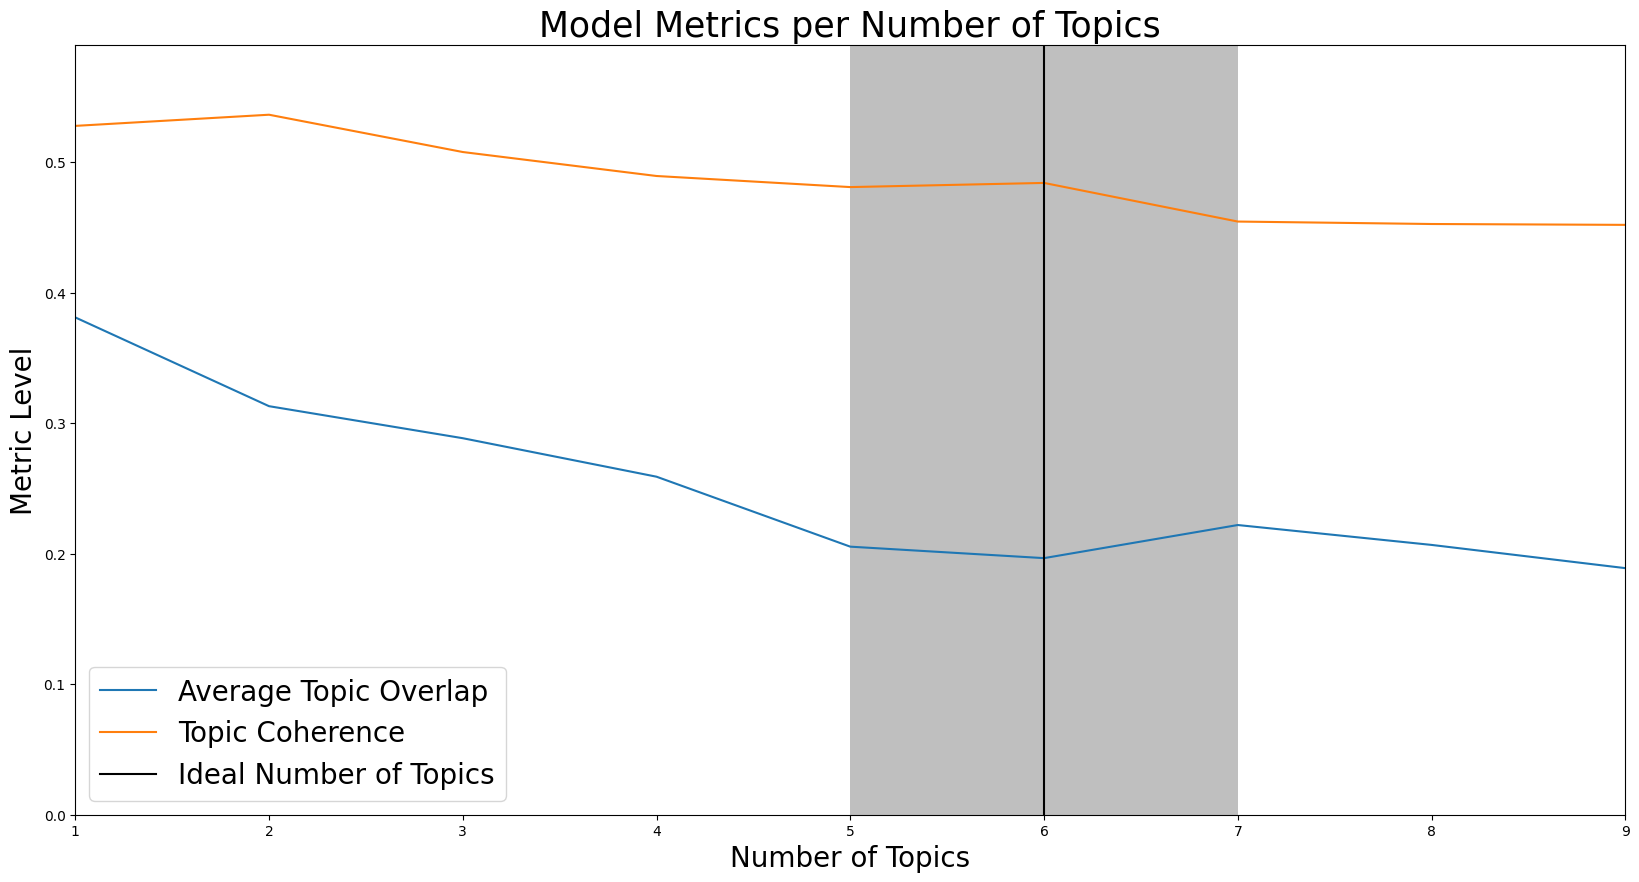

In [16]:
plt.figure(figsize=(20,10))
ax = sns.lineplot(x=num_topics[:-1], y=mean_stabilities, label='Average Topic Overlap')
ax = sns.lineplot(x=num_topics[:-1], y=coherences, label='Topic Coherence')

ax.axvline(x=ideal_topic_num, label='Ideal Number of Topics', color='black')
ax.axvspan(xmin=ideal_topic_num - 1, xmax=ideal_topic_num + 1, alpha=0.5, facecolor='grey')

y_max = max(max(mean_stabilities), max(coherences)) + (0.10 * max(max(mean_stabilities), max(coherences)))
ax.set_ylim([0, y_max])
ax.set_xlim([1, num_topics[-1]-1])
                
ax.axes.set_title('Model Metrics per Number of Topics', fontsize=25)
ax.set_ylabel('Metric Level', fontsize=20)
ax.set_xlabel('Number of Topics', fontsize=20)
plt.legend(fontsize=20)
plt.show()   


In [17]:
lda = LDA_models[5]

In [18]:
document_topics = [lda.get_document_topics(doc) for doc in doc_term_matrix_filtered]

# Display the topics and weights for each document
for i, doc_topics in enumerate(document_topics):
    print(f"Document {i}:")
    for topic, weight in doc_topics:
        print(f"  Topic {topic}: {weight:.4f}")

Document 0:
  Topic 3: 0.9892
Document 1:
  Topic 0: 0.4572
  Topic 1: 0.5266
Document 2:
  Topic 0: 0.0155
  Topic 1: 0.0159
  Topic 2: 0.0179
  Topic 3: 0.9393
  Topic 4: 0.0114
Document 3:
  Topic 2: 0.9927
Document 4:
  Topic 1: 0.9836
Document 5:
  Topic 1: 0.9796
Document 6:
  Topic 0: 0.3242
  Topic 2: 0.6682
Document 7:
  Topic 0: 0.3486
  Topic 4: 0.6406
Document 8:
  Topic 0: 0.9705
Document 9:
  Topic 1: 0.6441
  Topic 2: 0.3490
Document 10:
  Topic 2: 0.9920
Document 11:
  Topic 3: 0.9800
Document 12:
  Topic 0: 0.1636
  Topic 1: 0.8326
Document 13:
  Topic 1: 0.9603
  Topic 2: 0.0115
  Topic 3: 0.0109
Document 14:
  Topic 0: 0.2965
  Topic 1: 0.4789
  Topic 2: 0.1170
  Topic 3: 0.1060
Document 15:
  Topic 1: 0.9836
Document 16:
  Topic 3: 0.9831
Document 17:
  Topic 0: 0.9817
Document 18:
  Topic 1: 0.9863
Document 19:
  Topic 2: 0.9842
Document 20:
  Topic 2: 0.2343
  Topic 3: 0.7454
Document 21:
  Topic 2: 0.9814
Document 22:
  Topic 0: 0.3055
  Topic 3: 0.6830
Document 

In [19]:
# Assuming lda and doc_term_matrix are already defined
# Extract topics and their weights for each document
document_topics = [lda.get_document_topics(doc) for doc in doc_term_matrix_filtered]

# Convert the results to a DataFrame
doc_topic_df = pd.DataFrame([{f"Topic_{topic+1}": weight for topic, weight in doc_topics} for doc_topics in document_topics])
# Fill NaN values with 0 (if a topic is not present in a document, its weight is 0)
doc_topic_df = doc_topic_df.fillna(0)


doc_topic_df['ID']  = corpus_id 
doc_topic_df['gen'] = [df_advice['gen'][df_advice['ID'] == id].unique()[0] for id in corpus_id]
doc_topic_df

,Topic_4,Topic_1,Topic_2,Topic_3,Topic_5,ID,gen
0,0.989184,0.000000,0.000000,0.000000,0.000000,54249d5bfdf99b691e6ac9a0,9
1,0.000000,0.457131,0.526628,0.000000,0.000000,5466464dfdf99b7fec4402b0,2
2,0.939302,0.015493,0.015864,0.017932,0.011409,54b042f9fdf99b71c47ea96b,2
3,0.000000,0.000000,0.000000,0.992724,0.000000,54b19cadfdf99b0b3d806330,6
4,0.000000,0.000000,0.983623,0.000000,0.000000,557c0bd8fdf99b120dc45dde,1
...,...,...,...,...,...,...,...
995,0.000000,0.316332,0.000000,0.680800,0.000000,668bfbcbfd735b6652c60f20,10
996,0.010855,0.960045,0.010211,0.011545,0.000000,668bfc03a3529d7791c62b19,9
997,0.000000,0.000000,0.000000,0.989014,0.000000,668d371bd614f22c3433ea48,9
998,0.000000,0.000000,0.323901,0.650917,0.000000,668d5331aa58b7e75ff160d7,10


In [20]:
def joint_plot(x, y, data, title):
    g = sns.jointplot(x=x, y=y, data=data, kind='reg', color='#870052')
    slope, intercept, r_value, pv, se = stats.linregress(x=data[x], y=data[y])
    g.ax_joint.annotate(f'y={slope:.2f}x+{intercept:.2f} \n$\\rho = {r_value:.3f}, p = {pv:.3f}$',
                        xy=(0.1, 1), xycoords='axes fraction',
                        ha='left', va='center',
                        bbox={'boxstyle': 'round', 'fc': '#C7ECDC', 'ec': '#C7ECDC'})
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

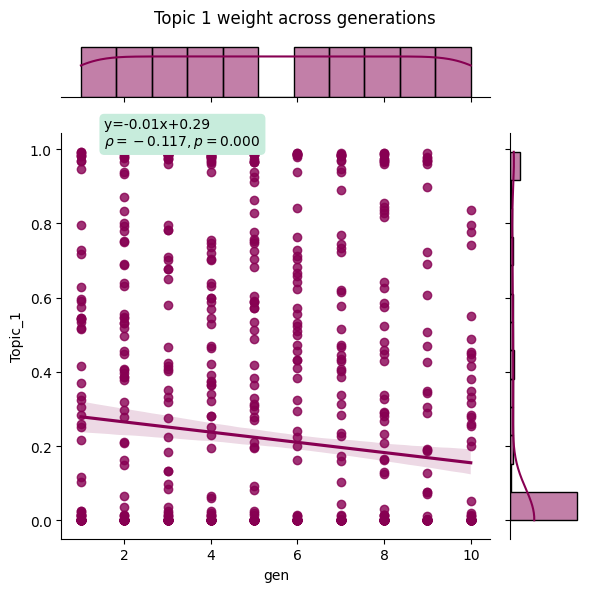

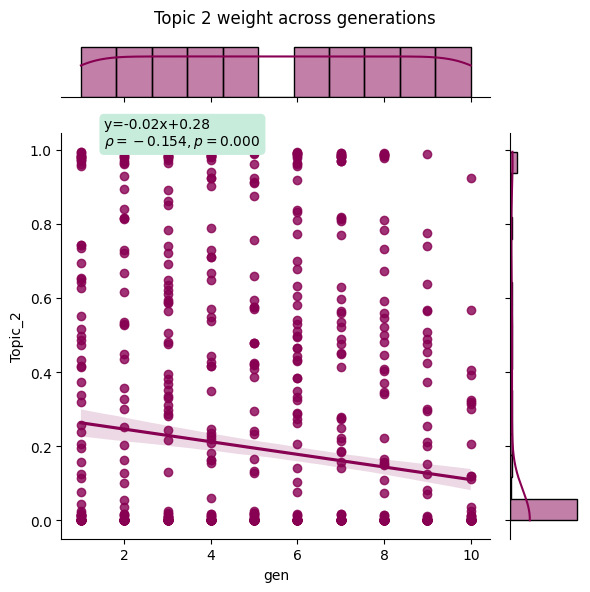

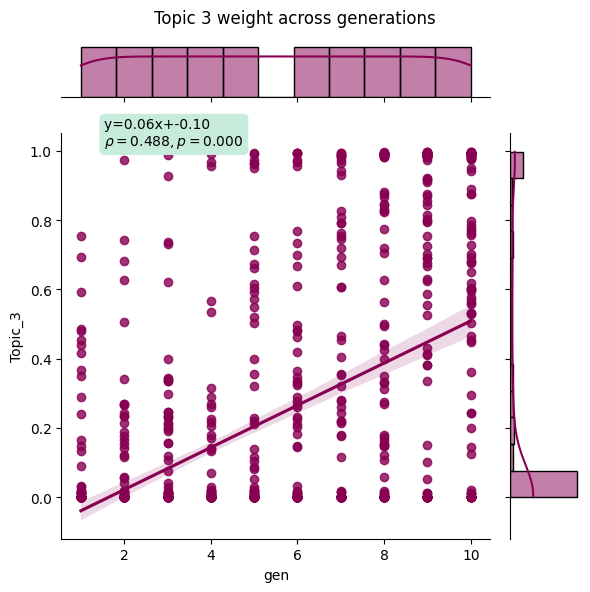

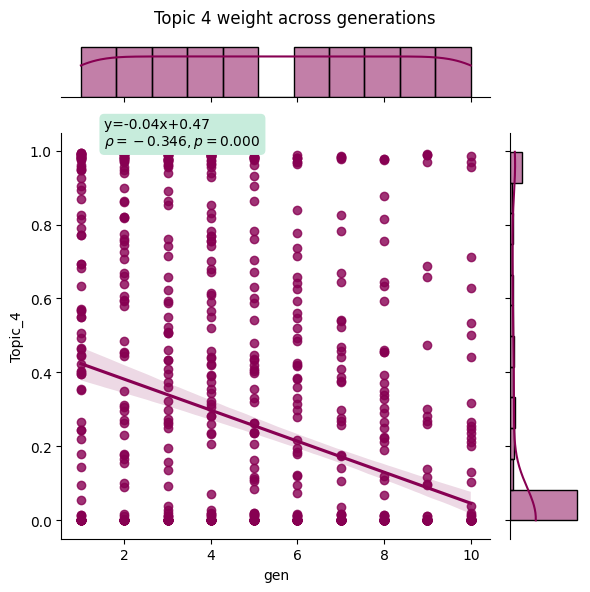

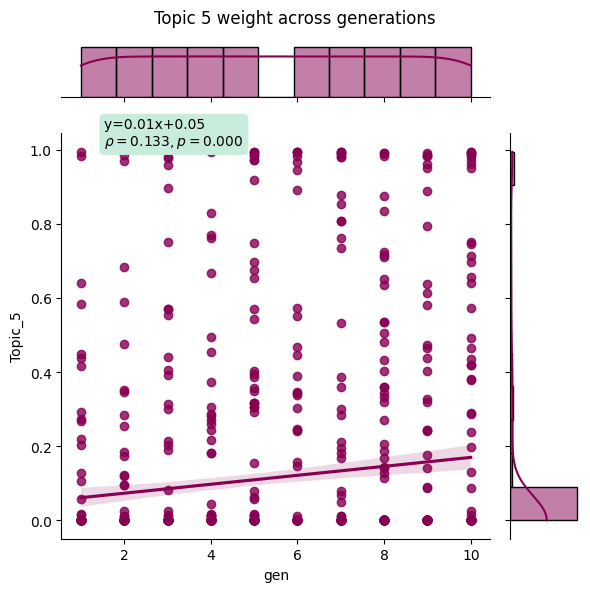

In [23]:
for topic in range(5):
    joint_plot('gen', f'Topic_{topic+1}', doc_topic_df, 
                f'Topic {topic+1} weight across generations')

In [24]:
df_whole = pd.merge(df, doc_topic_df, on=['ID', 'gen'])
df_whole.head()

,Unnamed: 0,ID,understanding_score,pl1_understanding,pl2_understanding,score_corrected,rank,filename,binary_score,ADVICE,...,parent_binary_score,parent_n_miss,W_h,W_l,W,Topic_4,Topic_1,Topic_2,Topic_3,Topic_5
0,1,557c0bd8fdf99b120dc45dde,0.450602,0.823568,0.077637,0.036000,61,231648_experiment_2024-05-15_18h56.19.209.csv,0.550781,Consider each round carefully as it appears th...,...,NaN,NaN,0.047,0.136,0.0915,0.000000,0.000000,0.983623,0.000000,0.0
1,2,55cca8f81676ab000ff06ef1,0.046999,0.068651,0.025347,-0.831984,98,977227_experiment_2024-05-15_18h41.00.488.csv,0.562500,"If the multiplier is 5, then choose the pointy...",...,NaN,NaN,0.825,0.022,0.4235,0.000000,0.000000,0.644120,0.348988,0.0
2,3,561f684fed6e5a000dc7e878,-0.011316,-0.072371,0.049740,0.065737,57,517641_experiment_2024-05-15_18h58.56.170.csv,0.550781,The game is fantastic but requires you to thin...,...,NaN,NaN,0.169,0.084,0.1265,0.979965,0.000000,0.000000,0.000000,0.0
3,4,56e9c7ac0a5579000d8f7dd4,0.493623,0.967023,0.020224,0.104839,55,187094_experiment_2024-05-15_18h45.57.869.csv,0.546875,My advice would be to pay attention to the col...,...,NaN,NaN,0.032,0.040,0.0360,0.000000,0.981736,0.000000,0.000000,0.0
4,5,57681fca8e454c000133a203,0.497338,0.941127,0.053548,0.462151,31,621764_experiment_2024-05-15_19h49.20.832.csv,0.566406,"Do not let the timer worry you, but make sure ...",...,NaN,NaN,0.022,0.057,0.0395,0.683010,0.305550,0.000000,0.000000,0.0


In [25]:
parent = df_whole['parent_ID']
parent

0                       fake 23
1                       fake 94
2                       fake 51
3                       fake 18
4                       fake 60
                 ...           
995    5f43bbbc0dab3463a47b93e0
996    6658c10539f5e53a96a6ad40
997    5a9bf9bd89de8200013f0f28
998    5c436d365140ec0001030b05
999    66730795fa560aa138fc5f91
Name: parent_ID, Length: 1000, dtype: object

In [26]:
df_whole['Parent_topic1_weight'] = None
df_whole['Parent_topic2_weight'] = None
df_whole['Parent_topic3_weight'] = None
df_whole['Parent_topic4_weight'] = None
df_whole['Parent_topic5_weight'] = None

In [27]:
for i, p in enumerate(parent):
    if 'fake' not in p:
        parent_topic1_weight = df_whole['Topic_1'][df_whole['ID'] == p].values[0]
        df_whole['Parent_topic1_weight'][i] = parent_topic1_weight
        
        parent_topic2_weight = df_whole['Topic_2'][df_whole['ID'] == p].values[0]
        df_whole['Parent_topic2_weight'][i] = parent_topic2_weight
        
        parent_topic3_weight = df_whole['Topic_3'][df_whole['ID'] == p].values[0]
        df_whole['Parent_topic3_weight'][i] = parent_topic3_weight

        parent_topic4_weight = df_whole['Topic_4'][df_whole['ID'] == p].values[0]
        df_whole['Parent_topic4_weight'][i] = parent_topic4_weight

        parent_topic5_weight = df_whole['Topic_5'][df_whole['ID'] == p].values[0]
        df_whole['Parent_topic5_weight'][i] = parent_topic5_weight


/var/folders/4c/kggkfd_s0mzb_dl8g2c8t1b80000gn/T/ipykernel_11974/3010358335.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_whole['Parent_topic1_weight'][i] = parent_topic1_weight
/var/folders/4c/kggkfd_s0mzb_dl8g2c8t1b80000gn/T/ipykernel_11974/3010358335.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_whole['Parent_topic2_weight'][i] = parent_topic2_weight
/var/folders/4c/kggkfd_s0mzb_dl8g2c8t1b80000gn/T/ipykernel_11974/3010358335.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/s

In [504]:
df_whole.to_csv('data/data_advice_topic.csv', index=False)

In [489]:
df_parent = df_whole.dropna(subset=['Parent_topic3_weight']).reset_index(drop=True)
df_parent['Parent_topic1_weight'] = df_parent['Parent_topic1_weight'].astype(float)
df_parent['Parent_topic2_weight'] = df_parent['Parent_topic2_weight'].astype(float)
df_parent['Parent_topic3_weight'] = df_parent['Parent_topic3_weight'].astype(float)
df_parent['Parent_topic4_weight'] = df_parent['Parent_topic4_weight'].astype(float)
df_parent['Parent_topic5_weight'] = df_parent['Parent_topic5_weight'].astype(float)

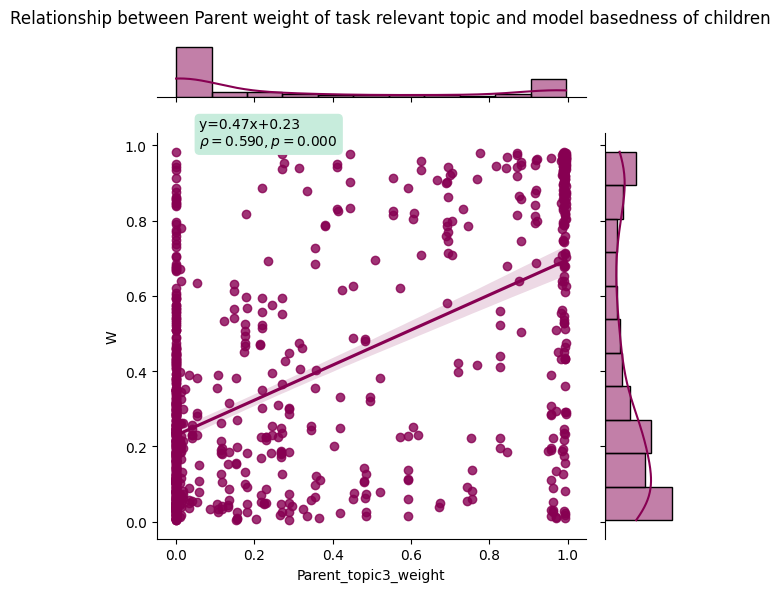

In [32]:
joint_plot('Parent_topic3_weight', 'W', df_parent, 
            f'Relationship between Parent weight of task relevant topic and model basedness of children')

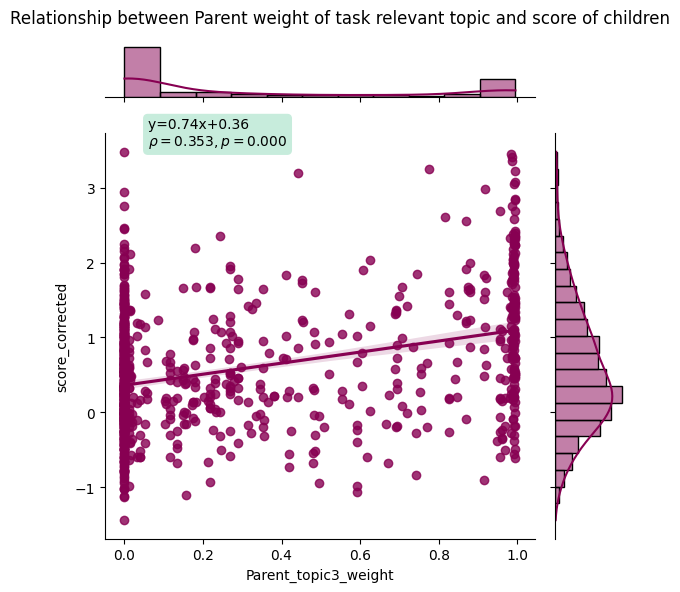

In [33]:
joint_plot('Parent_topic3_weight', 'score_corrected', df_parent, 
            f'Relationship between Parent weight of task relevant topic and score of children')

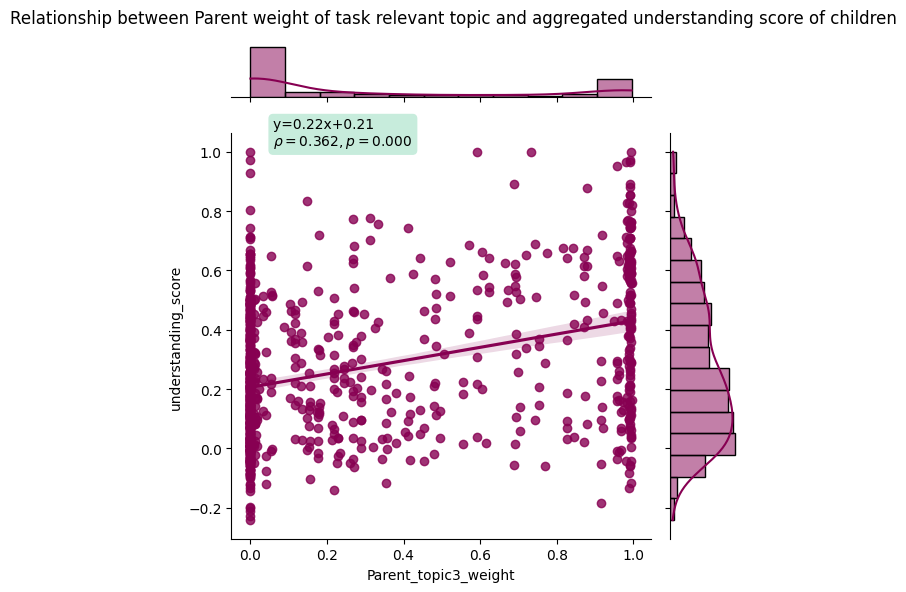

In [34]:
joint_plot('Parent_topic3_weight', 'understanding_score', df_parent, 
            f'Relationship between Parent weight of task relevant topic and aggregated understanding score of children')

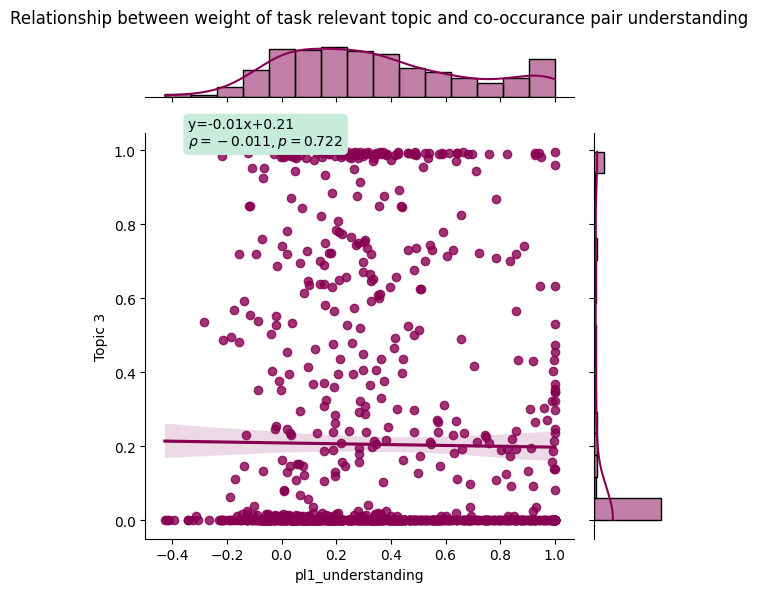

In [324]:
joint_plot('pl1_understanding', 'Topic 3', df_whole, 
            f'Relationship between weight of task relevant topic and co-occurance pair understanding')

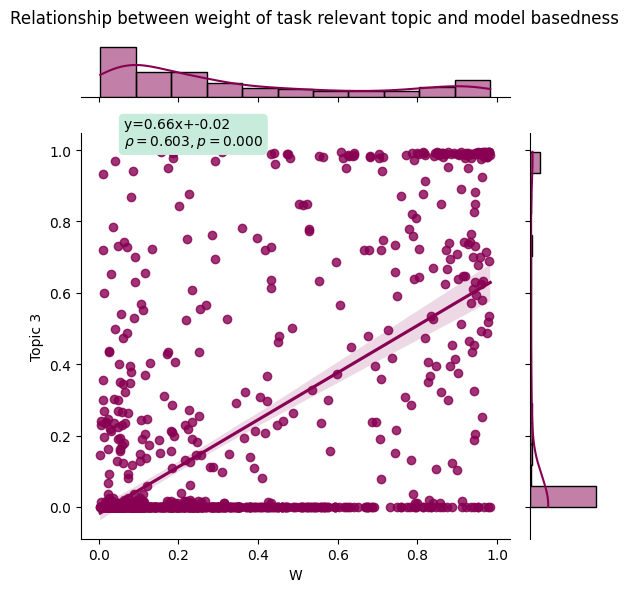

In [325]:
joint_plot('W', 'Topic 3', df_whole, 
            f'Relationship between weight of task relevant topic and model basedness')

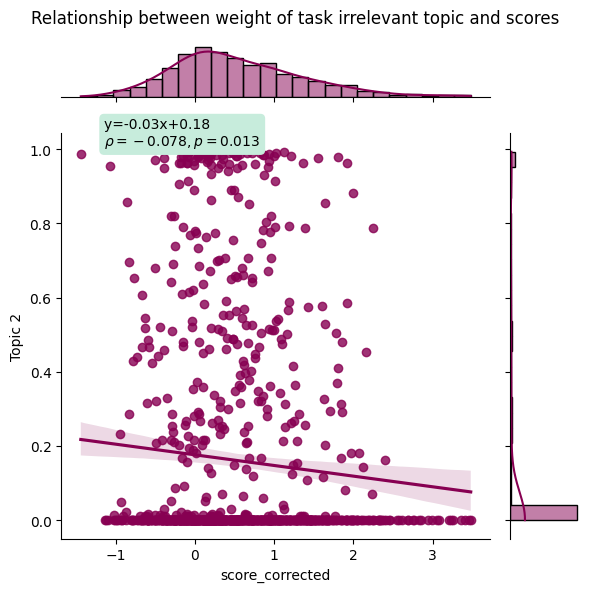

In [350]:
joint_plot('score_corrected', 'Topic 2', df_whole, 
            f'Relationship between weight of task irrelevant topic and scores')